### Imports and Preprocessing

In [1]:
import logging
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import umap
from dataclasses import asdict
from torch.utils.data import DataLoader

from utils import (
    load_patient_ids, pad_ucsf_ids, unpad_ucsf_ids, build_id_to_cohort, TDMapDataset,
    split_ids, save_splits, load_splits,
    build_dataset_from_ids,
    compute_bounding_box, bbox_to_padded_shape,
    compute_normalisation_stats, load_brain_mask,
    save_preprocessing_stats, load_preprocessing_stats
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

from dotenv import load_dotenv
load_dotenv()

import wandb

In [2]:
from config import Config

cfg = Config()
print(f"Device: {cfg.device}")

Device: cuda


In [3]:
patient_ids = load_patient_ids(cfg.gbm_root, cfg.cohort_dirs)
patient_ids["ucsf"] = pad_ucsf_ids(patient_ids["ucsf"])

print("\nSample UCSF IDs:", patient_ids["ucsf"][:5])

  UCSF     —  368 subjects  (CSV: (368, 27))
  UPENN    —  496 subjects  (CSV: (496, 18))
  RHUH     —   34 subjects  (CSV: (34, 33))
  TCGA     —  103 subjects  (CSV: (103, 22))

  Total: 1001 subjects across 4 cohorts

Sample UCSF IDs: ['UCSF-PDGM-0009', 'UCSF-PDGM-0004', 'UCSF-PDGM-0008', 'UCSF-PDGM-0011', 'UCSF-PDGM-0014']


In [4]:
splits = load_splits(cfg.splits_dir)

In [5]:
splits

{'test': ['UCSF-PDGM-0082',
  'UCSF-PDGM-0377',
  'UCSF-PDGM-0383',
  'UCSF-PDGM-0066',
  'UCSF-PDGM-0159',
  'UCSF-PDGM-0213',
  'UCSF-PDGM-0393',
  'UCSF-PDGM-0402',
  'UCSF-PDGM-0515',
  'UCSF-PDGM-0387',
  'UCSF-PDGM-0288',
  'UCSF-PDGM-0361',
  'UCSF-PDGM-0189',
  'UCSF-PDGM-0013',
  'UCSF-PDGM-0068',
  'UCSF-PDGM-0370',
  'UCSF-PDGM-0397',
  'UCSF-PDGM-0008',
  'UCSF-PDGM-0096',
  'UCSF-PDGM-0488',
  'UCSF-PDGM-0413',
  'UCSF-PDGM-0078',
  'UCSF-PDGM-0077',
  'UCSF-PDGM-0412',
  'UCSF-PDGM-0009',
  'UCSF-PDGM-0371',
  'UCSF-PDGM-0172',
  'UCSF-PDGM-0339',
  'UCSF-PDGM-0179',
  'UCSF-PDGM-0525',
  'UCSF-PDGM-0538',
  'UCSF-PDGM-0533',
  'UCSF-PDGM-0122',
  'UCSF-PDGM-0492',
  'UCSF-PDGM-0063',
  'UCSF-PDGM-0495',
  'UCSF-PDGM-0316',
  'UCSF-PDGM-0058',
  'UCSF-PDGM-0188',
  'UCSF-PDGM-0325',
  'UCSF-PDGM-0391',
  'UCSF-PDGM-0128',
  'UCSF-PDGM-0405',
  'UCSF-PDGM-0185',
  'UCSF-PDGM-0386',
  'UCSF-PDGM-0166',
  'UCSF-PDGM-0067',
  'UCSF-PDGM-0454',
  'UCSF-PDGM-0034',
  'UCSF-PDGM

In [6]:
stats = load_preprocessing_stats(cfg.preprocessing_path)
bbox, padded_shape, nm, ns = stats["bbox"], stats["padded_shape"], stats["norm_mean"], stats["norm_std"]

id_to_cohort = build_id_to_cohort(patient_ids)
brain_mask = load_brain_mask(cfg.brain_mask, bbox, padded_shape)

bbox, padded_shape, nm, ns 

({'z_min': 16,
  'z_max': 115,
  'y_min': 16,
  'y_max': 140,
  'x_min': 3,
  'x_max': 104},
 (112, 128, 112),
 15.94027054479829,
 65.34031310789675)

In [7]:
train_dataset = build_dataset_from_ids(splits["train"], id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask)
val_dataset   = build_dataset_from_ids(splits["val"],   id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask)
test_dataset  = build_dataset_from_ids(splits["test"],  id_to_cohort, cfg,
                                       bbox, padded_shape, nm, ns, cfg.normalisation, brain_mask)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

batch = next(iter(train_loader))
print(f"Preprocessed batch shape: {batch.shape}")

# TODO: fix comment?
assert all(s % 16 == 0 for s in batch.shape[2:]), "Spatial dims not divisible by 16 — check padded_shape"

Preprocessed batch shape: torch.Size([4, 1, 112, 128, 112])


# Analysis

In [8]:
from model import Autoencoder
import importlib
import config
importlib.reload(config)

from config import Config

cfg = Config()
print(f"Device: {cfg.device}")

model      = Autoencoder(
    input_shape=padded_shape,
    latent_dim=cfg.latent_dim,
    # channels=cfg.encoder_channels,
).to(cfg.device)

model.load_state_dict(torch.load(cfg.save_path, map_location=cfg.device))
model.eval()
print("Model loaded.")

Device: cuda
Model loaded.


#### nibabel plots

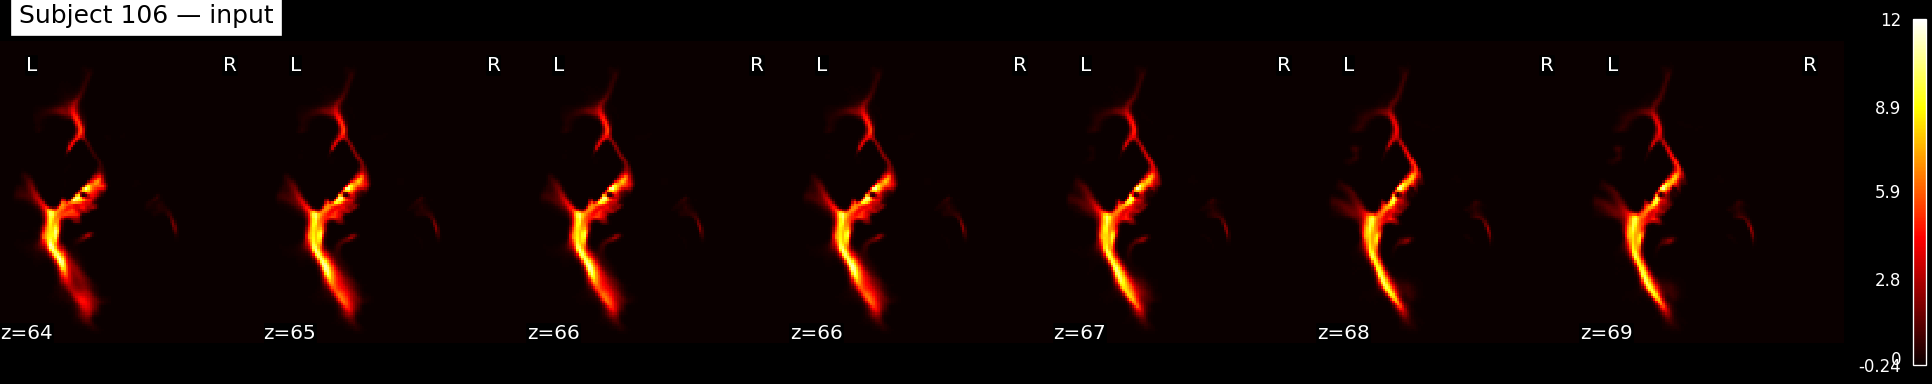

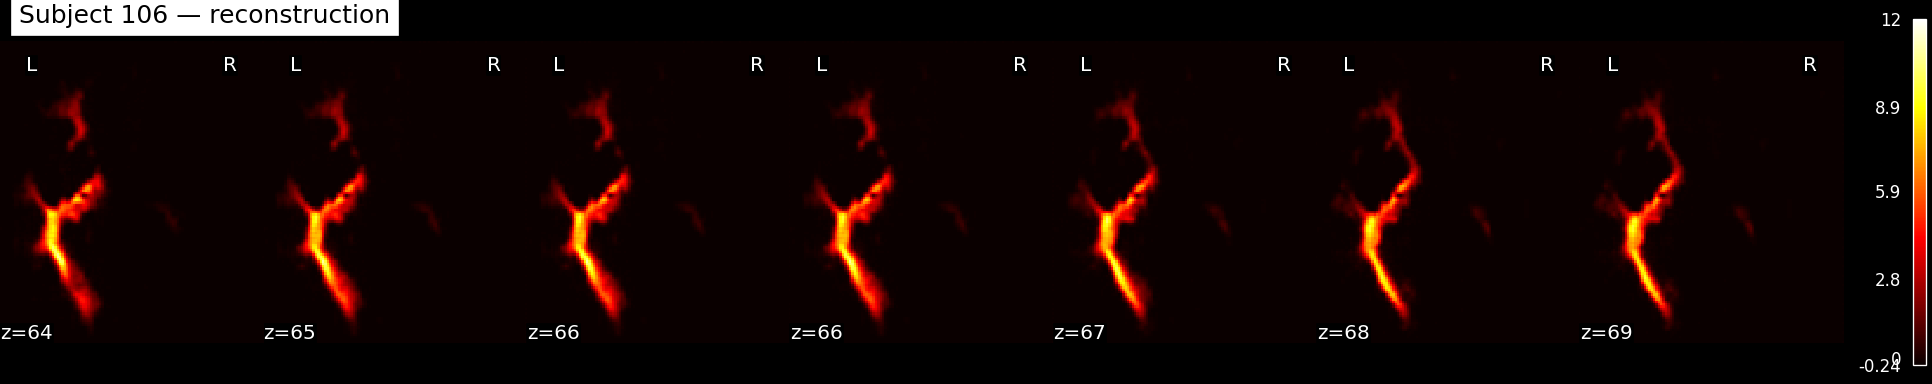

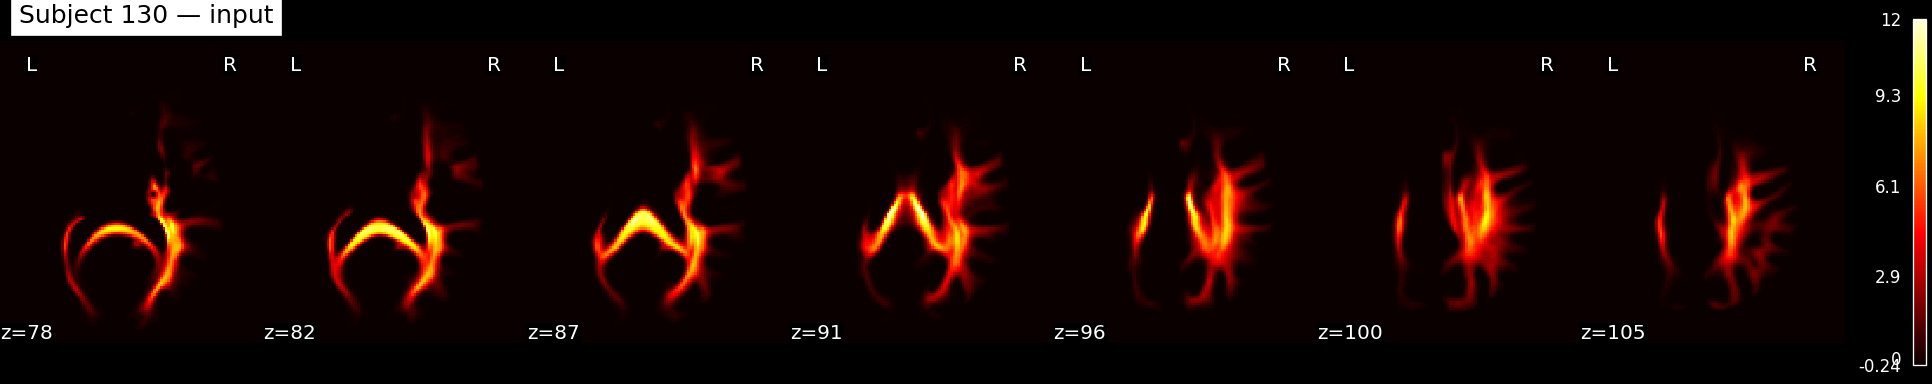

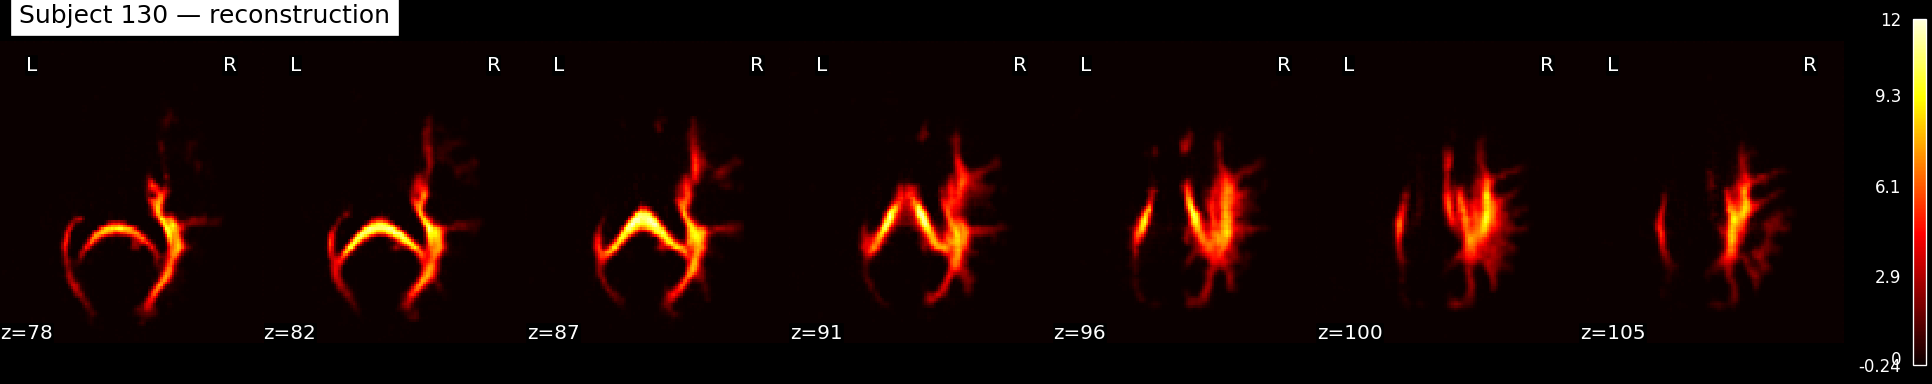

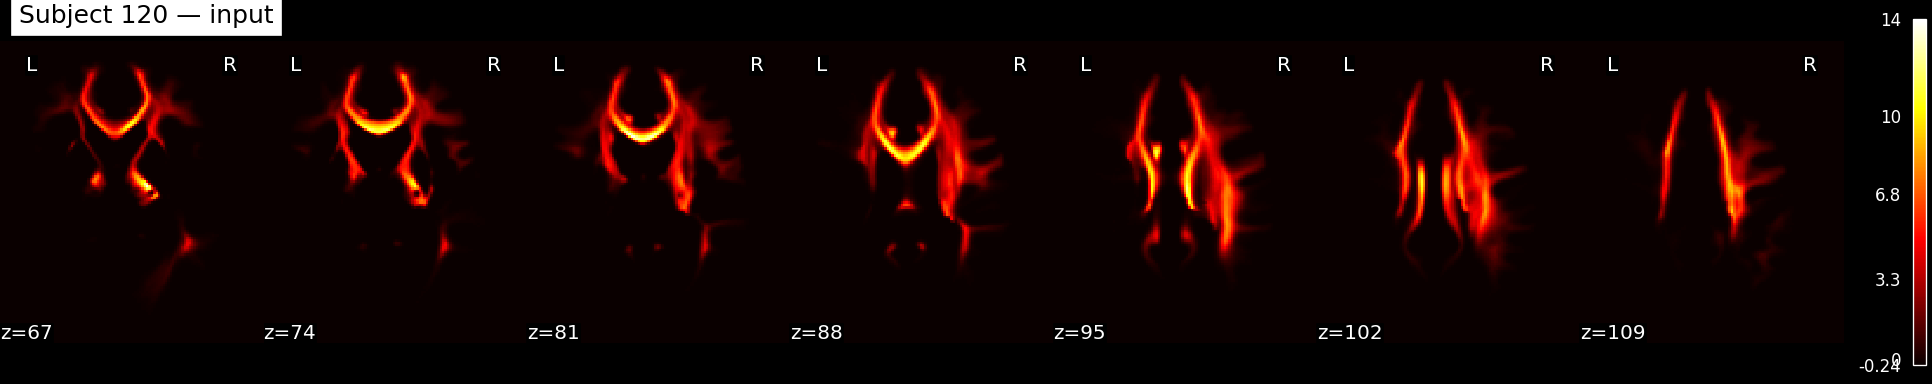

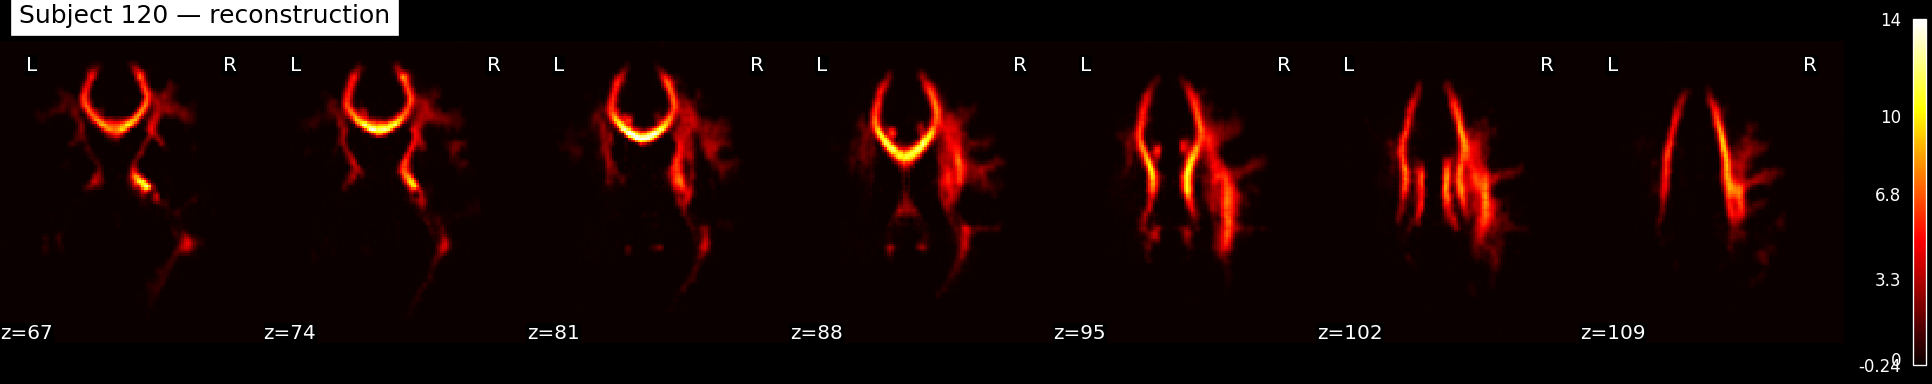

IndexError: index 0 is out of bounds for axis 0 with size 0

In [9]:
import nibabel as nib                                                                                      
from nilearn import plotting as nlplot
from IPython.display import Image as IPyImage
from IPython.display import display as nb_display                                                          
import tempfile                                                                                            
                                                                                                            
N_EXAMPLES = 6                                                                                             
N_SLICES   = 7  
indices    = random.sample(range(len(test_dataset)), N_EXAMPLES) 

affine = np.diag([cfg.voxel_res, cfg.voxel_res, cfg.voxel_res, 1.0])                                       
                
model.eval()
with torch.no_grad():
    for idx in indices:
        vol   = test_dataset[idx].unsqueeze(0).to(cfg.device)
        recon, _ = model(vol)

        inp_np = vol  [0, 0].cpu().numpy().astype(np.float32)
        rec_np = recon[0, 0].cpu().numpy().astype(np.float32)
        vmin, vmax = float(inp_np.min()), float(inp_np.max())                     

        z_signal  = inp_np.sum(axis=(0, 1))
        threshold = z_signal.max() * 0.02          # slices with at least 2% of peak slice signal
        nonzero_z = np.where(z_signal > threshold)[0]                                                              
        z_coords  = np.linspace(nonzero_z[0], nonzero_z[-1], N_SLICES) * cfg.voxel_res
        z_coords  = z_coords.tolist()                                     

        for label, data in [("input", inp_np), ("reconstruction", rec_np)]:                                
            with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
                fname = f.name
            disp = nlplot.plot_anat(
                nib.Nifti1Image(data, affine),
                display_mode="z",
                cut_coords=z_coords,
                vmin=vmin, vmax=vmax,
                colorbar=True,
                title=f"Subject {idx} — {label}",
                cmap="hot",
            )
            disp.savefig(fname, dpi=120)
            disp.close()
            nb_display(IPyImage(fname))



### Loading latent codes and visualisations

(1001, 4)
1001


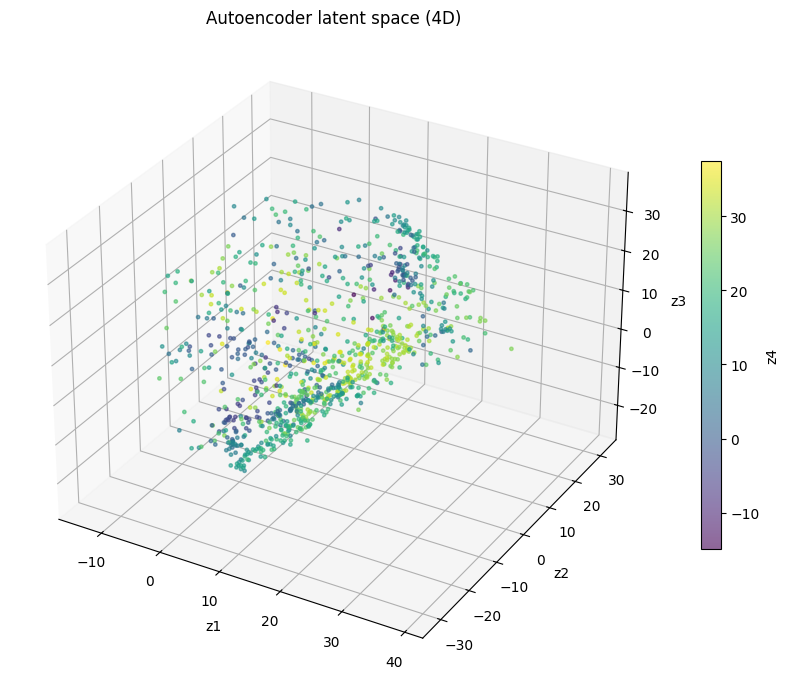

In [10]:
# # 2D visualisation
# codes   = torch.tensor(np.load(os.path.join(cfg.root, "latent_codes.npy")))
# all_ids = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()

# print(codes.shape)
# print(len(all_ids))

# plt.figure(figsize=(7, 6))
# plt.scatter(codes[:, 0], codes[:, 1], s=6, alpha=0.5)
# plt.title("Autoencoder latent space")
# plt.tight_layout()
# plt.savefig(os.path.join(cfg.root, "latent_space.png"), dpi=150)
# plt.show()

# 4D visualisation
from mpl_toolkits.mplot3d import Axes3D

codes   = np.load(os.path.join(cfg.root, "latent_codes.npy"))                                              
all_ids = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()
                                                                                                            
print(codes.shape)                                                                                       
print(len(all_ids))                                                                                        
                                                                                                        
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")
                                                                                                            
sc = ax.scatter(
    codes[:, 0], codes[:, 1], codes[:, 2],                                                                 
    c=codes[:, 3],                                                                                       
    cmap="viridis",                                                                                        
    s=6, alpha=0.6,
)                                                                                                          
plt.colorbar(sc, ax=ax, label="z4", shrink=0.6)                                                          
ax.set_xlabel("z1"); ax.set_ylabel("z2"); ax.set_zlabel("z3")                                              
ax.set_title("Autoencoder latent space (4D)")                                                              
plt.tight_layout()                                                                                         
plt.savefig(os.path.join(cfg.root, "latent_space.png"), dpi=150)                                           
plt.show()                                                                                                 

### COX models

In [11]:
import pandas as pd                                                                                        
import numpy as np                                                                                       
import os
from lifelines import CoxPHFitter

# load latent codes                                                                                        
codes   = np.load(os.path.join(cfg.root, "latent_codes.npy"))        # (N, 2)
all_ids = np.load(os.path.join(cfg.root, "latent_codes_ids.npy"), allow_pickle=True).tolist()      

for i, id in enumerate(all_ids):
    if 'UCSF' in id:
        all_ids[i] = unpad_ucsf_ids(id)
        
# codes
all_ids
codes_df = pd.DataFrame({
    "id": all_ids,                                                                                         
    "z1": codes[:, 0],                                                                                   
    "z2": codes[:, 1],
    "z3": codes[:, 2],
    "z4": codes[:, 3]                                                                                 
})

                                                                                                 
# load clinical CSV — adjust column names to match yours                                                 
clinical = pd.read_csv(cfg.clinical_csv)
# clinical["ID"]

# # clinical should have: patient id, OS days, event/status, age, sex                        
# clinical                                                                                               
# # merge on patient ID — adjust the id column name to match your CSV                                        
df = codes_df.merge(clinical, left_on="id", right_on="ID", how="inner")                         
df                                                                                         
# # drop rows missing survival info or covariates                                                            
df = df.dropna(subset=["OS (days) - corrected", "status", "z1", "z2", "z3", "z4"]) 
df                                    


,id,z1,z2,z3,z4,ID,age,sex,eor,mgmt,...,Core lesion TDMap,Non-enhancing TDMap,Non-enhancing lesion TDMap,Enhancing TDMap,Enhancing lesion TDMap,Core+Enhancing TDMap,Core+Enhancing lesion TDMap,cohort,site,OS (days) - corrected
0,UPENN-GBM-00147_11,6.593610,-29.104158,-0.575120,21.602322,UPENN-GBM-00147_11,82.41,1,1.0,0.0,...,0.804185,130.299588,2.866155,74.560762,1.046598,100.428056,1.047600,1,1,107.143828
1,UCSF-PDGM-430,17.850664,-15.106478,13.299091,23.579769,UCSF-PDGM-430,79.00,0,2.0,0.0,...,0.214835,255.461534,2.799048,133.118295,0.736955,123.039131,0.736956,0,0,406.000000
2,UCSF-PDGM-472,19.900066,12.616551,15.310995,25.006468,UCSF-PDGM-472,76.00,1,0.0,2.0,...,1.278647,124.437120,4.896154,117.381894,2.580636,123.730019,2.580733,0,0,38.000000
3,UCSF-PDGM-332,13.824084,-23.284601,0.967427,6.858371,UCSF-PDGM-332,68.00,0,2.0,2.0,...,0.736385,175.369296,5.865094,146.804520,1.725475,148.421375,1.725487,0,0,42.000000
4,UPENN-GBM-00337_11,-1.467530,-12.117081,-2.676670,-0.005526,UPENN-GBM-00337_11,62.34,0,2.0,NaN,...,2.775009,112.819121,4.693732,157.227826,3.901126,166.981916,3.917241,1,1,515.629674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,TCGA-02-0009,-5.578516,11.679451,-1.796227,19.282183,TCGA-02-0009,61.00,1,NaN,0.0,...,0.379249,70.014250,1.257232,148.231487,0.614384,88.865209,0.650983,2,1,430.967790
995,TCGA-06-0238,18.815598,-21.117586,9.054716,8.635073,TCGA-06-0238,46.00,0,NaN,NaN,...,0.466644,99.463595,3.751923,56.781503,0.673405,54.285974,0.678839,2,1,542.055761
996,TCGA-76-6664,10.276597,25.349844,21.779619,9.346524,TCGA-76-6664,49.00,1,NaN,2.0,...,0.462849,93.481570,3.777519,46.345565,0.955934,45.520411,1.009172,2,1,317.203001
997,TCGA-06-0241,7.281589,-31.561840,-1.403970,2.952844,TCGA-06-0241,65.00,1,NaN,NaN,...,0.780565,171.162536,1.740584,97.543244,1.220562,107.294998,1.223833,2,1,608.976225


In [12]:
df.groupby("cohort")["cohort"].value_counts()

cohort
0    367
1    496
2    103
3     33
Name: count, dtype: int64

In [14]:
# model 1: clinical only                                                                         
cph_clinical = CoxPHFitter()
cph_clinical.fit(                                                                                          
    df[["OS (days) - corrected", "status", "age", "sex"]],
    duration_col="OS (days) - corrected",                                                                  
    event_col="status",                                                                                  
)                                                                                                          
cph_clinical.print_summary()                                                                             

# model 2: latent codes only
cph_latent = CoxPHFitter()
cph_latent.fit(                                                                                            
    df[["OS (days) - corrected", "status", "z1", "z2", "z3", "z4"]],
    duration_col="OS (days) - corrected",                                                                  
    event_col="status",                                                                                  
)                                                                                                          
cph_latent.print_summary()
                                                                                                            
# model 3: clinical + latent codes                                                               
cph_full = CoxPHFitter()
cph_full.fit(
    df[["OS (days) - corrected", "status", "age", "sex", "z1", "z2", "z3", "z4"]],
    duration_col="OS (days) - corrected",                                                                  
    event_col="status",
)                                                                                                          
cph_full.print_summary()

# model 4: clinical + latent codes                                                               
cph_full_ = CoxPHFitter()
cph_full_.fit(
    df[["OS (days) - corrected", "status", "age", "sex", "z2"]],
    duration_col="OS (days) - corrected",                                                                  
    event_col="status",
)                                                                                                          
cph_full_.print_summary()

<lifelines.CoxPHFitter: fitted with 999 total observations, 188 right-censored observations>
             duration col = 'OS (days) - corrected'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 999
number of events observed = 811
   partial log-likelihood = -4779.40
         time fit was run = 2026-06-06 11:11:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.03      1.03      0.00            0.02            0.03                1.02                1.03
sex       -0.06      0.94      0.07           -0.20            0.08                0.81                1.08

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  8.02 <0.005     49.71
sex          0.00 -0.90   0.37      1.43
---
Concordance = 0.61
Partial AIC = 9562.79
log-likelihood ratio test = 67.80 on 2 df
-log2(p) of ll-ratio test = 48.91

<lifelines.CoxPHFitter: fitted with 999 total observations, 188 right-censored observations>
             duration col = 'OS (days) - corrected'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 999
number of events observed = 811
   partial log-likelihood = -4811.45
         time fit was run = 2026-06-06 11:11:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
z1        -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
z2         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
z3         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
z4        -0.00      1.00      0.00           -0.01            0.01                0.99                1.01

           cmp to     z    p  -log2(p)
covariate                             
z1           0.00 -0.47 0.64      0.64
z2           0.00  1.47 0.14      2.82
z3           0.00  0.99 0.32      1.64
z4           0.00 -0.09 0.92      0.11
---
Concordance = 0.52
Partial AIC = 9630.91
log-likelihood ratio test = 3.69 on 4 df
-log2(p) of ll-ratio test = 1.15

<lifelines.CoxPHFitter: fitted with 999 total observations, 188 right-censored observations>
             duration col = 'OS (days) - corrected'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 999
number of events observed = 811
   partial log-likelihood = -4776.87
         time fit was run = 2026-06-06 11:11:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.03      1.03      0.00            0.02            0.03                1.02                1.03
sex       -0.06      0.94      0.07           -0.21            0.08                0.81                1.08
z1        -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
z2         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
z3         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
z4        -0.00      1.00      0.00           -0.01            0.00                0.99                1.00

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  8.09 <0.005     50.55
sex          0.00 -0.88   0.38      1.40
z1           0.00 -0.71   0.48      1.06
z2           0.00  1.73   0.08      3.58
z3           0.00  1.10   0.27      1.88
z4           0.00 -0.58   0.56      0.84
---
Concordance = 0.62
Partial AIC = 9565.74
log-likelihood ratio test = 72.86 on 6 df
-log2(p) of ll-ratio test = 43.10

<lifelines.CoxPHFitter: fitted with 999 total observations, 188 right-censored observations>
             duration col = 'OS (days) - corrected'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 999
number of events observed = 811
   partial log-likelihood = -4777.97
         time fit was run = 2026-06-06 11:11:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.03      1.03      0.00            0.02            0.03                1.02                1.03
sex       -0.07      0.93      0.07           -0.21            0.07                0.81                1.07
z2         0.00      1.00      0.00           -0.00            0.01                1.00                1.01

           cmp to     z      p  -log2(p)
covariate                               
age          0.00  8.02 <0.005     49.78
sex          0.00 -0.99   0.32      1.64
z2           0.00  1.69   0.09      3.45
---
Concordance = 0.61
Partial AIC = 9561.94
log-likelihood ratio test = 70.65 on 3 df
-log2(p) of ll-ratio test = 48.20